Create a simple 5x5 grid maze where an agent needs to find the shortest path from a start
position to a goal. The agent will learn to navigate the maze using the Q-Learning algorithm.
Requirements:

Define the state space based on the agent’s position in the grid.

Implement the Q-Learning algorithm to learn the optimal path.

Visualize the learning process by showing the agent’s path over time.

In [47]:
import numpy as np

### Define the Environment
The environment consists of states, actions, and rewards. States and actions are inputs for the Q-learning AI agent, while the possible actions are the AI agent's outputs.
#### States
The states in the environment are all of the possible locations within the maze.

The AI agent's goal is to learn the shortest path between the goal and all of the other locations in the maze.

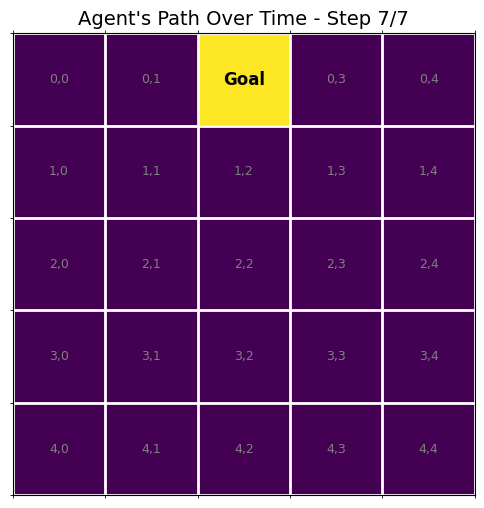

In the image above, there are 25 possible states (locations) within the maze. These states are arranged in a grid containing 5 rows and 5 columns. Each location can hence be identified by its row and column index.

In [48]:
#define the shape of the environment (i.e., its states)
environment_rows = 5
environment_columns = 5

#Create a 3D numpy array to hold the current Q-values for each state and action pair: Q(s, a)
#The array contains 5 rows and 5 columns (to match the shape of the environment), as well as a third "action" dimension.
#The "action" dimension consists of 4 layers that will allow us to keep track of the Q-values for each possible action in
#each state (see next cell for a description of possible actions).
#The value of each (state, action) pair is initialized to 0.
q_values = np.zeros((environment_rows, environment_columns, 4))

#### Actions
The actions that are available to the AI agent are to move the robot in one of four directions:
* Up
* Right
* Down
* Left

In [49]:
# define actions:
# here we use numeric action codes: 0 = up, 1 = right, 2 = down, 3 = left
actions = ['up', 'right', 'down', 'left']

# Reward:
to help the AI agent to learn, each state ie location in the maze is assigned a reward value.

The agent may begin at any white square, but its goal is always the same- to maximized its total rewards.

Negative rewared ie punishments are used for all the states except the goal.

This encourages the AI to identify the shrtest path to the goal by minimizing its punishments.


To maximize its cumulative rewards (by minimizing its cumulative punishments), the AI agent will need to fing the shortest paths.

In [50]:
# create a 2D numpy array to hold the rewards for each state:
# the array contains 5 rows and 5 columns and each value is initialized to -1:

rewards = np.full((environment_rows, environment_columns), -1.)
rewards[0,2]= 100

for row in rewards:
    print(row)

[ -1.  -1. 100.  -1.  -1.]
[-1. -1. -1. -1. -1.]
[-1. -1. -1. -1. -1.]
[-1. -1. -1. -1. -1.]
[-1. -1. -1. -1. -1.]


## Train the Model
now our AI agent has to learn about its environment by implementing Q-learning model. The learning process is as follows:
1. First choose a random, non-terminal state for the agent to begin.
2. Then choose an action (move up, right, down, or left) for the current state. Actions will be chosen using an Epsilon-Greedy Algorithm.
 This algorithm will usually choose the most promising action for the AI agent, but it will occasionally choose a less promising option in order to encourage the agent to explore the environment.
3. Then perform the chosen action, and transition to the next state (i.e., move to the next location).
4. Receive the reward for moving to the new state, and calculate the temporal difference.
5. Update the Q-value for the previous state and action pair.
6. If the new (current) state is a terminal state, go to step 1. Else, go to step 2.

This entire process will be repeated across 1000 times to train the AI agent.

### Helper functions

In [51]:
# define a function that determines if the specified location is a terminal state:
def is_terminal_state(current_row_index, current_column_index):
  # if the reward for this location is -1, then it is not a terminal state:
  if rewards[current_row_index, current_column_index] == -1.:
    return False
  else:
    return True


# define a function that will choose a random and non-terminal starting location:
def get_starting_location():
  # get a random row and column index
  current_row_index = np.random.randint(environment_rows)
  current_column_index = np.random.randint(environment_columns)
  #continue choosing random row and column indexes until a non-terminal state is identified:
  while is_terminal_state(current_row_index, current_column_index):
    current_row_index = np.random.randint(environment_rows)
    current_column_index = np.random.randint(environment_columns)
  return current_row_index, current_column_index


# define Epsilon Greedy Algo that will choose which action to take next or where to move next:
def get_next_action(current_row_index, current_column_index, epsilon):
  # if a randomly chosen value between 0 and 1 is less than epsilon, then choose the most promising value from the Q-table for this state.
  if np.random.random() < epsilon:
    return np.argmax(q_values[current_row_index, current_column_index])
  else:
    return np.random.randint(4)     # choose a random action


# define a function that will get the next location based on the chosen action:
def get_next_location(current_row_index, current_column_index, action_index):
  new_row_index = current_row_index
  new_column_index = current_column_index
  if actions[action_index] == 'up' and current_row_index > 0:
    new_row_index -= 1
  elif actions[action_index] == 'down' and current_row_index < environment_rows - 1:
    new_row_index += 1
  elif actions[action_index] == 'right' and current_column_index < environment_columns - 1:
    new_column_index += 1
  elif actions[action_index] == 'left' and current_column_index > 0:
    new_column_index -= 1
  return new_row_index, new_column_index


# Define a function that will get the shortest path between any location within the maze that the agent is allowed to travel:
def get_shortest_path(start_row_index, start_column_index):
  #return immediately if this is an invalid starting location:
  if is_terminal_state(start_row_index, start_column_index):
    return []
  else: #if this is a valid starting location:
    current_row_index, current_column_index = start_row_index, start_column_index
    shortest_path = []
    shortest_path.append([current_row_index, current_column_index])
    # continue moving along the path until we reach the goal:
    while not is_terminal_state(current_row_index, current_column_index):
      # get the best action to take
      action_index = get_next_action(current_row_index, current_column_index, 1.)
      # move to the next location on the path, and add the new location to the list
      current_row_index, current_column_index = get_next_location(current_row_index, current_column_index, action_index)
      shortest_path.append([current_row_index, current_column_index])
    return shortest_path

## Train the AI agent by using Q-learning:

In [52]:
# our training parameters:
epsilon = 0.9                # the percentage of time when we should take the best action instead of a random action
discount_factor = 0.9        # discount factor for future rewards
learning_rate = 0.9          # the rate at which the AI agent should learn

# run through 1000 training epochs:
for i in range(1000):
  row_index, column_index = get_starting_location()

  # continue taking actions until we reach a terminal state:
  while not is_terminal_state(row_index, column_index):
    # choose which action to take:
    action_index = get_next_action(row_index, column_index, epsilon)

    # perform the chosen action, and transition to the next state :
    old_row_index, old_column_index = row_index, column_index       # store the old row and column indexes
    row_index, column_index = get_next_location(row_index, column_index, action_index)

    # receive the reward for moving to the new state, and calculate the temporal difference:
    reward = rewards[row_index, column_index]
    old_q_value = q_values[old_row_index, old_column_index, action_index]
    temporal_difference = reward + (discount_factor * np.max(q_values[row_index, column_index])) - old_q_value

    # update the Q-value for the previous state and action pair:
    new_q_value = old_q_value + (learning_rate * temporal_difference)
    q_values[old_row_index, old_column_index, action_index] = new_q_value

print('Training complete!')

Training complete!


In [53]:
print(get_shortest_path(0,2)) 
print(get_shortest_path(4,0)) 
print(get_shortest_path(1,2))  

[]
[[4, 0], [4, 1], [3, 1], [2, 1], [2, 2], [1, 2], [0, 2]]
[[1, 2], [0, 2]]


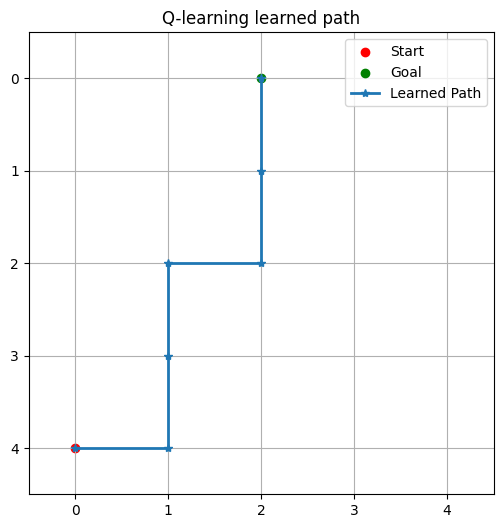

In [54]:
# to visualize the learning process by showing the agent’s path over time:
import matplotlib.pyplot as plt
Start = (4, 0)
Goal = (0, 2)
path = get_shortest_path(Start[0], Start[1])

plt.figure(figsize=(6, 6))

# draw grid
plt.xlim(-0.5, environment_columns - 0.5)
plt.ylim(environment_rows - 0.5, -0.5)
plt.xticks(range(environment_columns))
plt.yticks(range(environment_rows))
plt.grid(True)

# draw start
plt.scatter(Start[1], Start[0], label='Start', color='red')

# draw goal:
plt.scatter(Goal[1], Goal[0], label='Goal', color='green')

# draw path:
if path:
    path_rows = [position[0] for position in path]
    path_cols = [position[1] for position in path]
    plt.plot(path_cols, path_rows, marker='*', linewidth=2, label='Learned Path')

plt.title("Q-learning learned path")
plt.legend(loc='best')
plt.show()
